# LangChain agent + Geopack MCP (step-by-step)

Educational walkthrough — same pattern as [`examples/langchain_geopack_agent.py`](../examples/langchain_geopack_agent.py), but split into cells.

1. Load environment (`GEOPACK_*`, `OPENAI_*`)
2. Discover MCP tools via **langchain-mcp-adapters** (in-process in Jupyter)
3. Build a LangChain ReAct agent
4. Run your prompt with `await` (no `asyncio.run` in notebooks)
5. Show results as an HTML table with thumbnails

**Prerequisites:** API running, `notebooks/.env` configured.

In [2]:
%pip install -q python-dotenv nest_asyncio
%pip install -q -e "../.[langchain]"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:

import sys
from pathlib import Path

import nest_asyncio
from dotenv import load_dotenv

nest_asyncio.apply()

NOTEBOOK_DIR = Path.cwd()
SDK_ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR / "lib").is_dir() else NOTEBOOK_DIR
sys.path.insert(0, str(SDK_ROOT / "src"))
sys.path.insert(0, str(SDK_ROOT / "notebooks" / "lib"))

load_dotenv(SDK_ROOT / "notebooks" / ".env")
load_dotenv(SDK_ROOT / ".env")


from notebook_langchain import setup_notebook_paths, load_env

SDK_ROOT = setup_notebook_paths()
load_env(SDK_ROOT)
print("SDK root:", SDK_ROOT)

SDK root: D:\Works\geopack-geoportal\geopack-geoportal-v2\python-sdk


## Step 1 — Environment

In [3]:
import os

print("GEOPACK_API_URL:", os.getenv("GEOPACK_API_URL"))
print("OPENAI_MODEL:", os.getenv("OPENAI_MODEL", "gpt-4o-mini"))
print("OPENAI_BASE_URL:", os.getenv("OPENAI_BASE_URL") or "(default OpenAI)")
assert os.getenv("GEOPACK_API_URL") and os.getenv("OPENAI_API_KEY"), "Set GEOPACK_* and OPENAI_API_KEY in notebooks/.env"

GEOPACK_API_URL: http://localhost:3000/api
OPENAI_MODEL: openai/gpt-4o
OPENAI_BASE_URL: https://models.github.ai/inference


## Step 2 — Discover Geopack MCP tools

In Jupyter we use **in-process** MCP (same handlers as `geopack-sdk-mcp`). In a terminal script you would use stdio + `MultiServerMCPClient` — see the `examples/` folder.

In [4]:
from notebook_langchain import notebook_mcp_langchain_tools

if "mcp_ctx" in globals() and mcp_ctx is not None:
    await mcp_ctx.__aexit__(None, None, None)
mcp_ctx = notebook_mcp_langchain_tools()
tools, mcp_session, transport = await mcp_ctx.__aenter__()

print(f"Transport: {transport}")
print(f"Discovered {len(tools)} tools:")
for t in tools:
    print(f"  - {t.name}")

Transport: inprocess
Discovered 11 tools:
  - geopack_sdk_geocode_place
  - geopack_sdk_list_datasets
  - geopack_sdk_get_dataset
  - geopack_sdk_query_dataset
  - geopack_sdk_get_dataset_thumbnail
  - geopack_sdk_export_dataset
  - geopack_sdk_get_task
  - geopack_sdk_wait_for_task
  - geopack_sdk_list_workflows
  - geopack_sdk_get_workflow_run
  - geopack_sdk_download_generated_file


## Step 3 — Create LangChain agent

In [5]:
from langchain.agents import create_agent
from notebook_langchain import create_chat_model, SIMPLE_SYSTEM_PROMPT

llm = create_chat_model()
agent = create_agent(
    llm,
    tools,
    system_prompt=SIMPLE_SYSTEM_PROMPT,
)
print("Agent ready.")

Agent ready.


## Step 4 — Run natural-language prompt

Edit the prompt below. Example: *Find raster datasets in the Tehran area.*

In [6]:
USER_PROMPT = "Find raster datasets in the Tehran area."

print("User:", USER_PROMPT)
agent_result = await agent.ainvoke({"messages": USER_PROMPT})

User: Find raster datasets in the Tehran area.


HTTP Request: POST https://models.github.ai/inference/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://models.github.ai/inference/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://models.github.ai/inference/chat/completions "HTTP/1.1 200 OK"


## Step 5 — Assistant reply

In [12]:
from notebook_langchain import last_assistant_text
from display_datasets import print_tool_trace
messages = agent_result.get("messages", [])
print_tool_trace(messages)
print("\n--- Assistant ---\n")
print(last_assistant_text(agent_result))

--- Tool trace ---
  → geopack_sdk_geocode_place({"query": "Tehran"})
    ← {"display_name": "\u0634\u0647\u0631 \u062a\u0647\u0631\u0627\u0646, \u0628\u062e\u0634 \u0645\u0631\u06a9\u0632\u06cc \...
  → geopack_sdk_list_datasets({"bbox": "51.0892219,35.5682071,51.6063007,35.8284702", "data_type": "raster", "details_level": "lite", "page_size": 5})
    ← {"datasets": [{"id": 2422, "name": "hillshade12", "description": "sdf (Source: hillshade_1_output.tif)", "dataType": "ra...

--- Assistant ---

Here are 5 raster datasets in the Tehran area:

1. **hillshade12** (ID: 2422) - Source: hillshade_1_output.tif
2. **hillshade12** (ID: 2418) - Source: hillshade_1_output.tif
3. **hillshade12** (ID: 2417) - Source: hillshade_1_output.tif
4. **hillshade12** (ID: 2343) - Source: hillshade_1_output.tif
5. **LC80120292013170LGN00_NDVI.tif** (ID: 2311) - NDVI dataset

Let me know if you need more details or additional datasets.


## Step 6 — Dataset table + thumbnails

Parses `geopack_sdk_list_datasets` tool output and fetches preview PNGs via MCP.

Found 5 dataset row(s) in tool history.


Preview,ID,Name,Type,Updated
,2422,hillshade12,raster,2026-05-18T06:52:19.766000Z
,2418,hillshade12,raster,2026-05-18T04:46:45.874000Z
,2417,hillshade12,raster,2026-05-17T08:04:43.611000Z
,2343,hillshade12,raster,2026-05-11T05:56:26.363000Z
,2311,LC80120292013170LGN00_NDVI.tif,raster,2026-05-05T06:51:29.511000Z

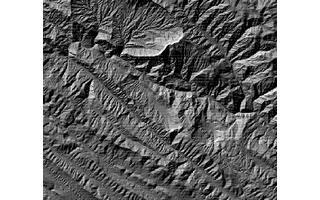
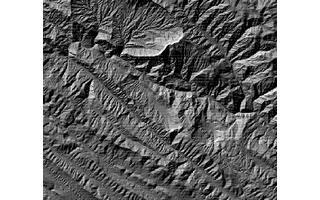
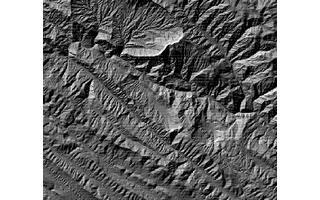
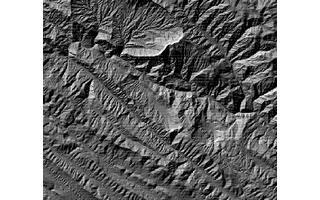
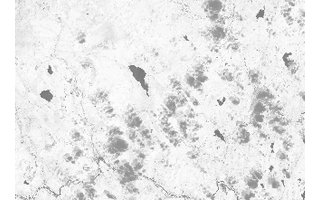

In [8]:
from notebook_langchain import extract_list_datasets_from_messages
from display_datasets import display_datasets_rich

datasets = extract_list_datasets_from_messages(messages)
print(f"Found {len(datasets)} dataset row(s) in tool history.")
await display_datasets_rich(datasets, mcp_session, max_rows=8)

In [9]:
# Cleanup MCP context (optional re-run Step 2 if you execute again)
await mcp_ctx.__aexit__(None, None, None)

False